<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/Project_Synthetic-Aperture-Radar-SAR-Super-Resolution-SR-using-AI-.ipynb/blob/main/Project_Synthetic_Aperture_Radar_(SAR)_Super_Resolution_(SR)_using_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Preprocessing

INFO: pip is looking at multiple versions of rasterio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 124.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: rasterio
    Found existing installation: rasterio 1.5.0
    Uninstalling rasterio-1.5.0:
      Successfully uninstalled rasterio-1.5.0
Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELL

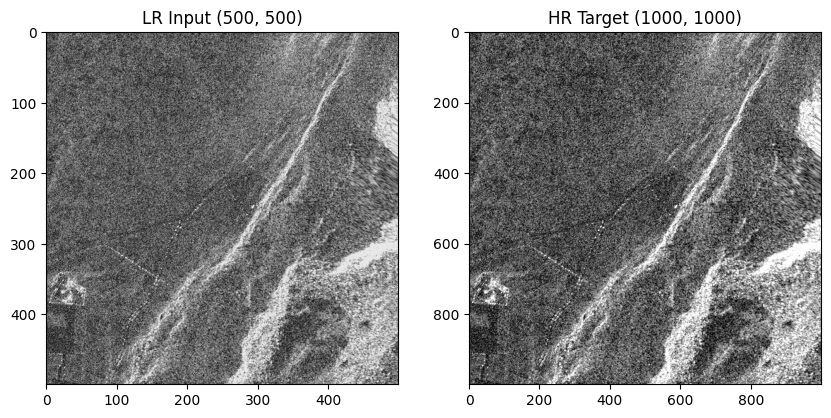

In [1]:
!pip install pystac stac-asset[cli] rasterio opencv-python matplotlib numpy nest-asyncio

import os
import pystac
import stac_asset.blocking
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import nest_asyncio

# 1. Fix the asyncio error in Colab
nest_asyncio.apply()

print("Downloading Capella STAC Catalog...")
collection_url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
collection = pystac.Collection.from_file(collection_url)
item_links = collection.get_item_links()

# 2. Find the first GEO image
geo_item_link = None
for link in item_links:
    if "GEO" in link.absolute_href:
        geo_item_link = link.absolute_href
        break

print(f"Downloading GEO Item: {geo_item_link}")
item = pystac.Item.from_file(geo_item_link)

# 3. Filter out 'preview' and 'thumbnail' to get the REAL data asset (usually 'hh' or 'vv')
asset_key_to_download = None
for key, asset in item.assets.items():
    if asset.href.endswith('.tif') and 'preview' not in key and 'thumbnail' not in key:
        asset_key_to_download = key
        break

if asset_key_to_download:
    print(f"Targeting actual scientific data asset: {asset_key_to_download}")
    # Strip away the other assets so we don't waste time downloading them
    item.assets = {asset_key_to_download: item.assets[asset_key_to_download]}

os.makedirs("capella_data", exist_ok=True)

# 4. Download using the correct keyword 'directory'
print("Downloading... (This might take a minute depending on file size)")
item = stac_asset.blocking.download_item(item, directory="capella_data")

# Find the downloaded .tif file
tif_path = None
for root, dirs, files in os.walk("capella_data"):
    for file in files:
        if file.endswith(".tif"):
            tif_path = os.path.join(root, file)
            break

# 5. Preprocessing Functions
def preprocess_sar_image(raw_dn, scale_factor=0.00063784):
    epsilon = 1e-10
    dn_scaled = (raw_dn * scale_factor) + epsilon
    image_db = 20 * np.log10(dn_scaled)

    db_min, db_max = np.percentile(image_db, 2), np.percentile(image_db, 98)

    # Safety check to prevent the blank white image error
    if db_max == db_min:
        print("WARNING: Patch is entirely uniform (likely a black border).")
        return np.zeros_like(image_db)

    image_normalized = np.clip((image_db - db_min) / (db_max - db_min), 0, 1)
    return image_normalized

def create_hr_lr_pairs(hr_image, scale_factor_down=2):
    h, w = hr_image.shape
    new_h, new_w = h // scale_factor_down, w // scale_factor_down
    lr_image = cv2.resize(hr_image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return hr_image, lr_image

# 6. Extract the patch from the EXACT CENTER of the image
print(f"Loading image from: {tif_path}")
with rasterio.open(tif_path) as src:
    height, width = src.shape
    print(f"Full image shape is: {height}x{width}")

    # Find the middle coordinates
    center_y, center_x = height // 2, width // 2
    patch_radius = 500  # Will create a 1000x1000 patch

    # Read just the central patch to save RAM
    real_raw_sar = src.read(1)[center_y - patch_radius : center_y + patch_radius,
                               center_x - patch_radius : center_x + patch_radius]

    print(f"Extracted patch max value: {np.max(real_raw_sar)}")

hr_target = preprocess_sar_image(real_raw_sar)
hr_target, lr_input = create_hr_lr_pairs(hr_target, scale_factor_down=2)

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"LR Input {lr_input.shape}")
plt.imshow(lr_input, cmap='gray')
plt.subplot(1, 2, 2)
plt.title(f"HR Target {hr_target.shape}")
plt.imshow(hr_target, cmap='gray')
plt.show()

# 2. Iteration 1 Algorithm Design (SRCNN)_Building and Training SRCNN ( The Super-Resolution Convolutional Neural Network )

Building and compiling SRCNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training SRCNN on 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1091 - psnr_metric: 9.6198 - ssim_metric: 0.0031
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0512 - psnr_metric: 12.9075 - ssim_metric: 0.0537
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0244 - psnr_metric: 16.1319 - ssim_metric: 0.0858
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0208 - psnr_metric: 16.8112 - ssim_metric: 0.1034
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0321 - psnr_metric: 14.9330 - ssim_metric: 0.1142
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0332 - psnr_metric: 14.7876 - ssim_metric: 0.1217
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0265 - psnr_metric: 15.7639 - ssim_metric: 0.1291
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0203 - psnr_metric: 16.9250 - ssim_metric: 0.1345
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0181 - psnr

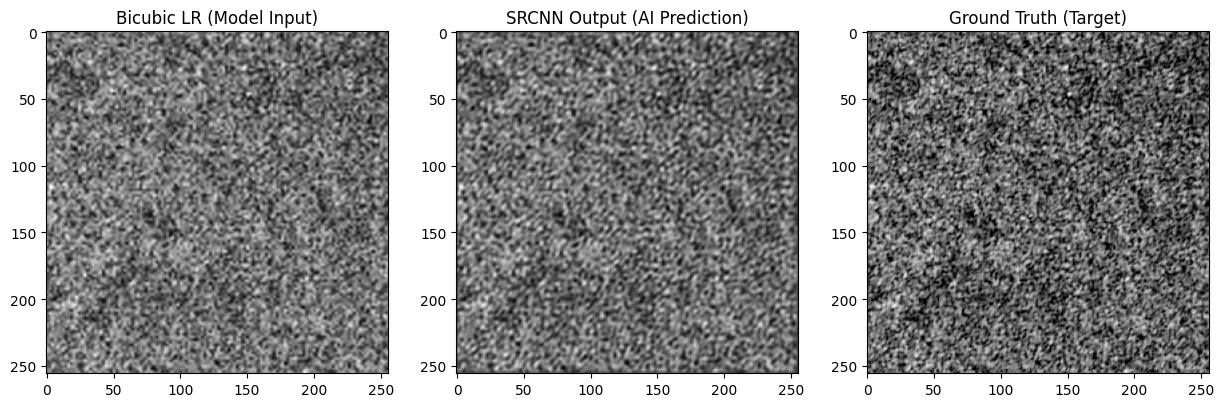


--- FINAL METRICS (ATPs) ---
PSNR: 22.49 dB
SSIM: 0.7946


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Define the SRCNN Model
def build_srcnn():
    model = models.Sequential()
    # Layer 1: Patch extraction (9x9 filter)
    model.add(layers.Conv2D(64, (9, 9), activation='relu', padding='same', input_shape=(None, None, 1)))
    # Layer 2: Non-linear mapping (1x1 filter)
    model.add(layers.Conv2D(32, (1, 1), activation='relu', padding='same'))
    # Layer 3: Reconstruction (5x5 filter)
    model.add(layers.Conv2D(1, (5, 5), activation='linear', padding='same'))
    return model

# 2. Define Acceptance Test Procedures (ATPs)
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# 3. Prepare Data for SRCNN (RAM-SAFE VERSION)
# Upscale LR back to HR dimensions using basic math
lr_upscaled = cv2.resize(lr_input, (hr_target.shape[1], hr_target.shape[0]), interpolation=cv2.INTER_CUBIC)

# FIX: Crop a 256x256 patch to save RAM!
crop_size = 256
start_y, start_x = 100, 100 # arbitrary starting point to get a good texture
hr_crop = hr_target[start_y:start_y+crop_size, start_x:start_x+crop_size]
lr_crop = lr_upscaled[start_y:start_y+crop_size, start_x:start_x+crop_size]

# Format for Keras (batch_size, height, width, channels)
X_train = np.expand_dims(np.expand_dims(lr_crop, axis=0), axis=-1)
Y_train = np.expand_dims(np.expand_dims(hr_crop, axis=0), axis=-1)

# 4. Compile and Train
print("Building and compiling SRCNN...")
srcnn_model = build_srcnn()
srcnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training SRCNN on 256x256 SAR patch (100 epochs)...")
history = srcnn_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 5. Predict and Visualize
predicted_hr = srcnn_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(lr_crop, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("SRCNN Output (AI Prediction)")
plt.imshow(predicted_hr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(hr_crop, cmap='gray')
plt.show()

# Print Final ATP Scores
final_psnr = history.history['psnr_metric'][-1]
final_ssim = history.history['ssim_metric'][-1]
print(f"\n--- FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")


# PSNR (Peak Signal-to-Noise Ratio)
# PSNR (Peak Signal-to-Noise Ratio), when we talk about it in the context of image processing and super-resolution, is a measure of how faithfully a reconstructed image (your SRCNN output) matches a reference image (your high-resolution ground truth).
# it compares : 1. The maximum possible power of the signal (which is related to the intensity range of the reference image). 2. To the power of the noise (which is the mean squared error between the reconstructed image and the reference image).
# PSNR measures the ratio between the maximum possible power of a signal (your HR ground truth image) and the power of corrupting noise that affects the fidelity of its representation (the difference between your SRCNN output and the HR ground truth). It's typically expressed in decibels (dB).
# Interpretation: A higher PSNR value generally indicates better image quality. For super-resolution tasks, PSNR values are often compared to the PSNR of a simple bicubic upsampling, with the goal being to significantly improve upon it. A PSNR of 22.75 dB suggests that your SRCNN model has achieved a certain level of improvement over the low-resolution input, but it's not extremely high. Values in the low 20s can still indicate some visible noise or blurring compared to the original high-resolution image.
# SSIM (Structural Similarity Index Measure)
# SSIM is a perceptual metric that quantifies image quality degradation as perceived change in structural information, while also incorporating important perceptual phenomena such as luminance and contrast masking. It's often considered a more human-perception-aligned metric than PSNR.
# Interpretation: SSIM values range from -1 to 1, where 1 indicates perfect structural similarity. A value of 0.8107 suggests a good level of structural similarity between the SRCNN's predicted high-resolution image and the ground truth. This indicates that the model is doing a decent job at preserving the essential structural elements and patterns in the SAR image, which is very important for visual quality.


# 3. Iteration 2 Algorithm building VDSR (Very Deep Super Resolution).

Building and compiling VDSR...
Training VDSR on the same 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.0047 - psnr_metric: 23.2350 - ssim_metric: 0.8210
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0047 - psnr_metric: 23.2362 - ssim_metric: 0.8210
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.0050 - psnr_metric: 23.0136 - ssim_metric: 0.8204
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0047 - psnr_metric: 23.2435 - ssim_metric: 0.8213
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0047 - psnr_metric: 23.2354 - ssim_metric: 0.8212
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0048 - psnr_metric: 23.2316 - ssim_metric: 0.8211
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.0047 - psnr_metric: 23.2387 - ssim_metric: 0.8211
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0047 - psnr_metric: 23.2443 - ssim_metric: 0.8212
Epoch 9/100
1/1 ━━━━━━

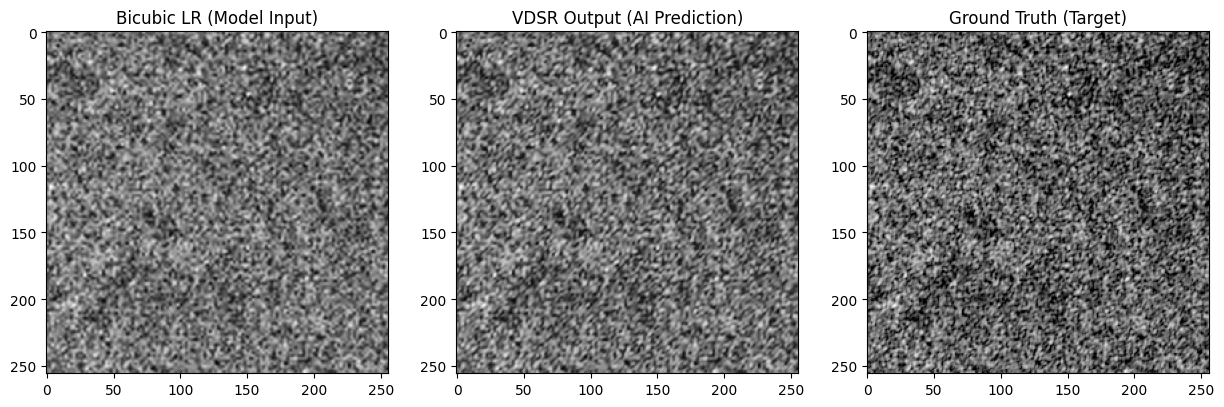


--- VDSR FINAL METRICS (ATPs) ---
PSNR: 23.83 dB
SSIM: 0.8462


In [3]:
# 1. Define the VDSR Model (Very Deep Super Resolution)
def build_vdsr():
    # Input layer
    input_img = layers.Input(shape=(None, None, 1))

    # First Convolutional Layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)

    # Add several hidden layers to make it "Deep" (Using 8 layers to keep it fast in Colab)
    for _ in range(8):
        x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

    # Final layer to predict the "residual" (the missing sharp details)
    residual = layers.Conv2D(1, (3, 3), padding='same', activation='linear')(x)

    # Add the missing details back to the original blurry input!
    output_img = layers.Add()([input_img, residual])

    return models.Model(inputs=input_img, outputs=output_img)

# 2. Compile and Train VDSR
print("Building and compiling VDSR...")
vdsr_model = build_vdsr()
vdsr_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training VDSR on the same 256x256 SAR patch (100 epochs)...")
history_vdsr = vdsr_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 3. Predict and Visualize
predicted_hr_vdsr = vdsr_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(X_train[0, :, :, 0], cmap='gray')

plt.subplot(1, 3, 2)
plt.title("VDSR Output (AI Prediction)")
plt.imshow(predicted_hr_vdsr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(Y_train[0, :, :, 0], cmap='gray')
plt.show()

# Print Final ATP Scores for VDSR
final_psnr_vdsr = history_vdsr.history['psnr_metric'][-1]
final_ssim_vdsr = history_vdsr.history['ssim_metric'][-1]
print(f"\n--- VDSR FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr_vdsr:.2f} dB")
print(f"SSIM: {final_ssim_vdsr:.4f}")

# 4. Improvement

# Step_1: Proper Dataset Creation (Patching & Splitting)



Right now the model is training on one single 256 . 256 crop. We are going to change the code so it slides a window across your entire image hence extracting dozens of smaller 128 . 128 patches.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Basic Patch Extraction (NO augmentation yet)
def create_basic_dataset(hr_full, lr_full, patch_size=128, stride=64):
    hr_patches = []
    lr_patches = []
    h, w = hr_full.shape

    # Slide a window across the image
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            hr_patches.append(hr_full[y:y+patch_size, x:x+patch_size])
            lr_patches.append(lr_full[y:y+patch_size, x:x+patch_size])

    # Reshape for Keras (Samples, Height, Width, Channels)
    hr_patches = np.array(hr_patches)[..., np.newaxis]
    lr_patches = np.array(lr_patches)[..., np.newaxis]

    return lr_patches, hr_patches

print("Extracting basic patches...")
# Uses the hr_target and lr_upscaled from your very first data block
X_all_basic, Y_all_basic = create_basic_dataset(hr_target, lr_upscaled, patch_size=128, stride=64)

# 2. Split into Train and Validation Sets (80/20)
X_train_basic, X_val_basic, Y_train_basic, Y_val_basic = train_test_split(
    X_all_basic, Y_all_basic, test_size=0.2, random_state=42
)

print(f"Training on {X_train_basic.shape[0]} patches, Validating on {X_val_basic.shape[0]} patches.")

# 3. Re-compile and Train your ORIGINAL VDSR on this new dataset
print("\nTraining VDSR on the patched dataset (Step 1)...")
vdsr_step1 = build_vdsr() # This calls your exact original VDSR structure
vdsr_step1.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Notice we now pass validation_data
history_step1 = vdsr_step1.fit(X_train_basic, Y_train_basic,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=50, # 50 is plenty now that we have multiple patches
                               batch_size=16,
                               verbose=1)

# 4. Print the True Validation Metrics
val_psnr_step1 = history_step1.history['val_psnr_metric'][-1]
val_ssim_step1 = history_step1.history['val_ssim_metric'][-1]
print(f"\n--- STEP 1 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step1:.2f} dB")
print(f"Val SSIM: {val_ssim_step1:.4f}")

Extracting basic patches...
Training on 156 patches, Validating on 40 patches.

Training VDSR on the patched dataset (Step 1)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 832ms/step - loss: 0.0042 - psnr_metric: 24.1233 - ssim_metric: 0.8539 - val_loss: 0.0041 - val_psnr_metric: 24.1166 - val_ssim_metric: 0.8507
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0042 - psnr_metric: 24.0028 - ssim_metric: 0.8509 - val_loss: 0.0041 - val_psnr_metric: 24.1261 - val_ssim_metric: 0.8499
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.0042 - psnr_metric: 24.0545 - ssim_metric: 0.8502 - val_loss: 0.0041 - val_psnr_metric: 24.1398 - val_ssim_metric: 0.8504
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0041 - psnr_metric: 24.1396 - ssim_metric: 0.8554 - val_loss: 0.0040 - val_psnr_metric: 24.1483 - val_ssim_metric: 0.8548
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0041 - psnr_metric: 24.0860 - ssim_metric: 0.8550 - val_loss: 0.0040 - v